DATA IMPORT

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Superstore Sales Datasets.csv", encoding='latin1')

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

Understand the DATASET

In [2]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.describe())

(9800, 18)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null 

DATA CLEANING


In [3]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [4]:
print(df.duplicated().sum())

0


In [5]:
df.drop('Postal Code', axis=1, inplace=True)

In [6]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


CONVERT Order_Date in Date Format

In [17]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [19]:
df['Month'] = df['Order Date'].dt.month_name()

In [20]:
df['Year'] = df['Order Date'].dt.year

In [18]:
print(df['Order Date'].head())

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order Date, dtype: datetime64[ns]


ANALYSIS

MONTHLY SALES TREND

In [21]:
month_order = ['January','February','March','April',
               'May','June','July','August',
               'September','October','November','December']

monthly_sales = df.groupby('Month')['Sales'].sum().reindex(month_order)

print(monthly_sales)

Month
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64


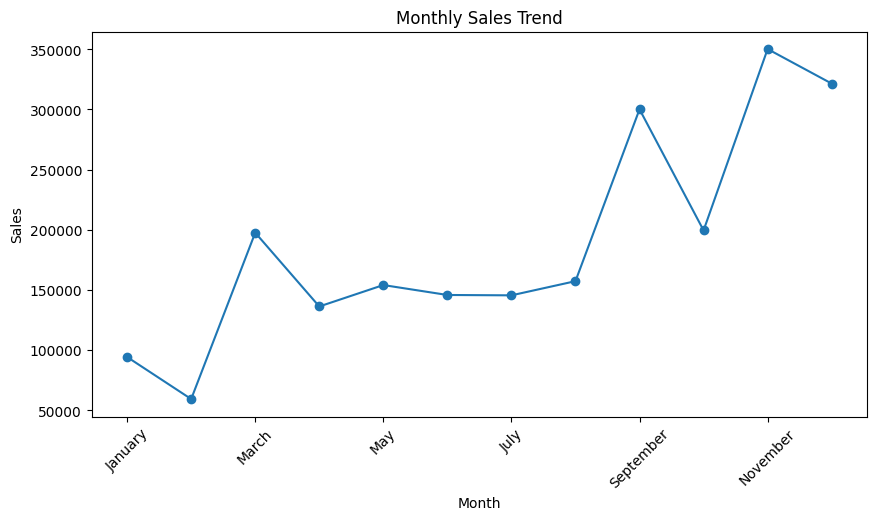

In [22]:
monthly_sales.plot(kind='line', marker='o', figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

## Insights: Monthly Sales Trend

- The lowest sales were recorded in February, with sales around 60,000, indicating a weak sales period during the beginning of the year.

- Sales increased significantly in March, showing a sharp recovery compared to February.

- From April to August, sales remained relatively stable, ranging between approximately 140,000 and 160,000.

- A major growth in sales was observed in September, where sales crossed 300,000, indicating a high-demand period.

- After a slight decline in October, the highest sales were achieved in November, reaching nearly 350,000.

- December also recorded strong sales performance, remaining above 320,000.

- Overall, the analysis indicates that sales tend to increase during the end of the year, suggesting the impact of festive seasons, promotional campaigns, or increased customer demand.

YEAR-WISE SALES

In [23]:
yearly_sales = df.groupby('Year')['Sales'].sum()

print(yearly_sales)

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


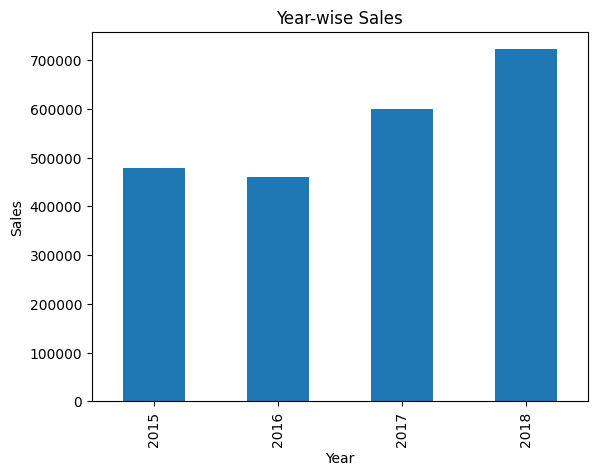

In [24]:
yearly_sales.plot(kind='bar')

plt.title("Year-wise Sales")

plt.ylabel("Sales")

plt.show()

## Insights: Year-wise Sales Analysis

- The sales performance showed a slight decline from 2015 to 2016, decreasing from approximately 480,000 to 460,000.

- A significant growth in sales was observed in 2017, where total sales increased to around 600,000.

- The highest sales were recorded in 2018, reaching approximately 720,000, indicating strong business growth.

- The continuous increase in sales from 2016 to 2018 suggests improved market performance and increasing customer demand.

- The overall trend indicates that the company experienced substantial sales growth over the years.

CATEGORY-WISE SALES

In [25]:
category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


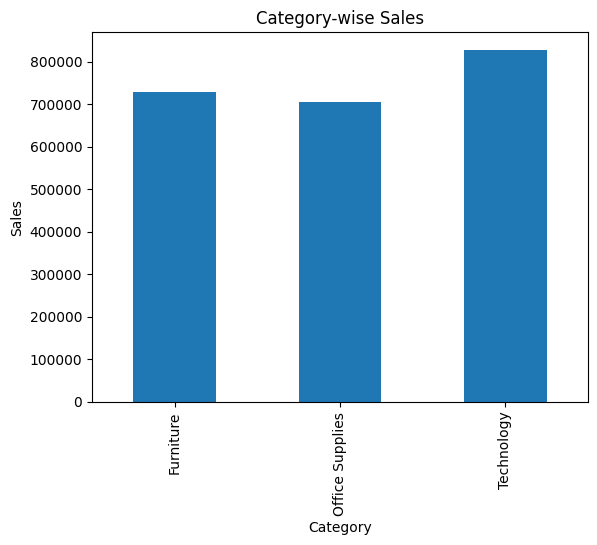

In [26]:
category_sales.plot(kind='bar')

plt.title("Category-wise Sales")

plt.ylabel("Sales")

plt.show()

## Insights: Category-wise Sales Analysis

- Technology category generated the highest sales, exceeding approximately 820,000, making it the best-performing category.

- Furniture category recorded sales of around 730,000, showing strong customer demand.

- Office Supplies generated the lowest sales among the three categories, with approximately 700,000 in total sales.

- Although the difference between Furniture and Office Supplies was relatively small, Technology maintained a clear lead.

- The findings suggest that customers spend more on technology products, highlighting their importance in overall business revenue.

SUB-CATEGORY ANALYSIS

In [27]:
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

print(sub_sales)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


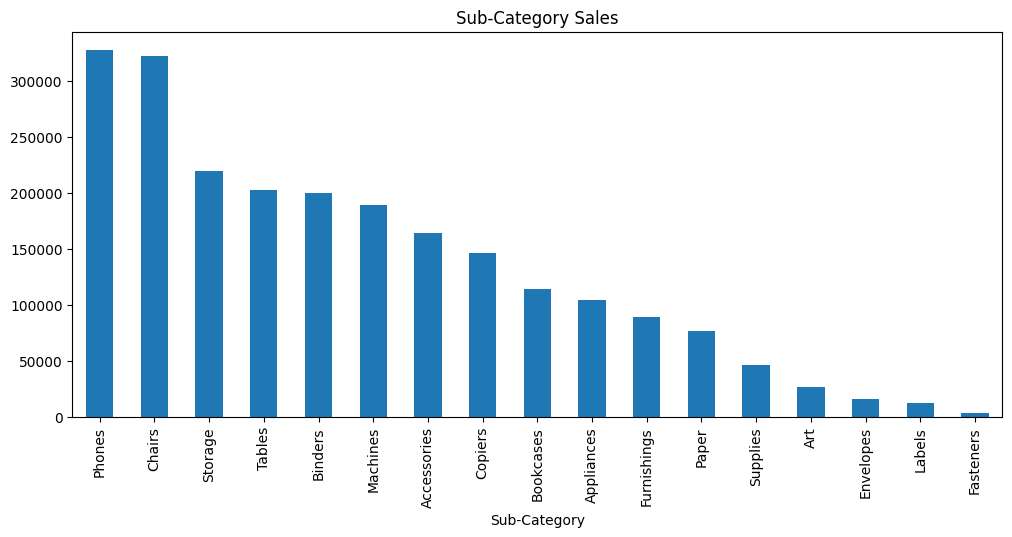

In [28]:
sub_sales.plot(kind='bar', figsize=(12,5))

plt.title("Sub-Category Sales")

plt.show()

## Insights: Sub-Category Sales Analysis

- Phones emerged as the highest-selling sub-category, generating sales of more than 330,000.

- Chairs ranked second in terms of sales performance, contributing approximately 320,000 in total sales.

- Storage, Tables, and Binders also performed well, indicating consistent customer demand.

- Fasteners recorded the lowest sales among all sub-categories, contributing only a small portion to total revenue.

- Labels and Envelopes also generated relatively low sales compared to other product groups.

- The significant variation in sales across sub-categories highlights differences in customer preferences and purchasing behavior.

- High-performing sub-categories such as Phones and Chairs should receive greater focus in inventory planning and promotional activities.

REGION-WISE SALES

In [29]:
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


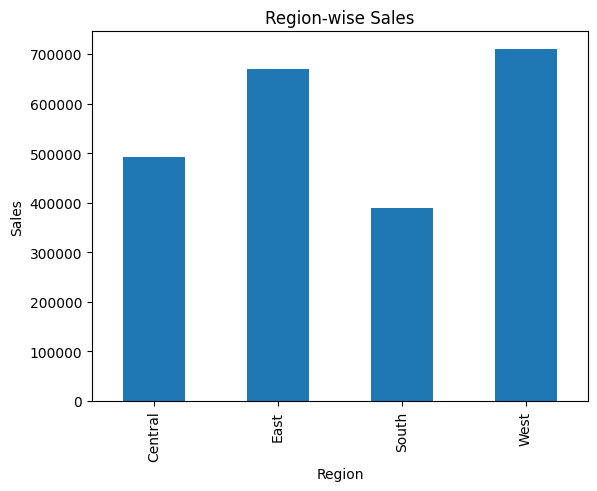

In [30]:
region_sales.plot(kind='bar')

plt.title("Region-wise Sales")

plt.ylabel("Sales")

plt.show()

## Insights: Region-wise Sales Analysis

- West region generated the highest sales, reaching approximately 710,000, making it the top-performing region.

- East region recorded sales of around 670,000, indicating strong market performance and customer demand.

- Central region achieved sales of nearly 490,000, placing it in the middle of the overall regional ranking.

- South region generated the lowest sales, with approximately 390,000 in total sales.

- The gap between the highest-performing region (West) and the lowest-performing region (South) is significant, highlighting regional disparities in sales performance.

- West and East regions together contributed the majority of total sales, demonstrating their importance to overall business revenue.

- The comparatively lower sales in the South region suggest opportunities for targeted marketing campaigns, improved distribution strategies, and customer engagement initiatives.

- The analysis indicates that strengthening performance in lower-performing regions could help achieve a more balanced and sustainable sales distribution across all regions.

SEGMENT-WISE SALES

In [31]:
segment_sales = df.groupby('Segment')['Sales'].sum()

print(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


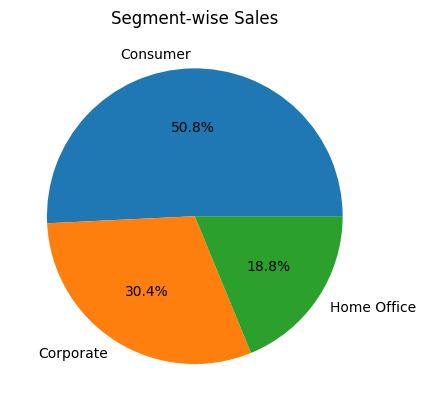

In [32]:
segment_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Segment-wise Sales")

plt.ylabel("")

plt.show()

## Insights: Segment-wise Sales Analysis

- The Consumer segment contributed the highest share of total sales, accounting for approximately 50.8% of overall revenue.

- Corporate customers generated around 30.4% of total sales, making it the second-largest revenue-contributing segment.

- The Home Office segment contributed approximately 18.8% of total sales, representing the smallest share among all customer segments.

- More than half of the company's sales originated from the Consumer segment, highlighting its importance as the primary customer base.

- The significant difference between the Consumer and Home Office segments indicates varying purchasing behaviors and market demand across customer groups.

- The Corporate segment maintained a strong contribution, suggesting consistent demand from business customers and organizations.

- The relatively lower contribution from the Home Office segment presents an opportunity for targeted marketing campaigns and product offerings to increase engagement and sales.

- The analysis suggests that while the business is heavily reliant on Consumer sales, strengthening Corporate and Home Office segments could help diversify revenue sources and improve overall business stability.

# Conclusion

The Sales Trend Visualization project successfully analyzed historical sales data to identify important business patterns and customer preferences.

The analysis revealed that sales performance improved significantly during the latter part of the year, with November recording the highest monthly sales, while February showed the lowest sales performance.

Year-wise analysis indicated a positive growth trend, with 2018 emerging as the best-performing year and demonstrating continuous business expansion after 2016.

Among the product categories, Technology generated the highest sales, highlighting its major contribution to overall revenue. Furniture and Office Supplies also contributed significantly to total sales.

Sub-category analysis showed that Phones and Chairs were the strongest revenue-generating products, whereas Fasteners, Labels, and Envelopes recorded the lowest sales.

Overall, the findings suggest that understanding sales trends and customer preferences can help organizations make informed decisions related to inventory management, marketing strategies, and resource allocation. Data visualization proved to be an effective tool for transforming raw sales data into meaningful business insights.